Calculate baseline failure rate across all the transactions.

In [1]:
import pandas as pd
df = pd.read_csv('../data/transactions_raw.csv')

baseline = df['is_failed'].mean()*100
print("Baseline Failure Rate:", round(baseline,2),"%")

Baseline Failure Rate: 23.37 %


The baseline failure rate across all 10,000 transactions is 23.37%. 
This is the system average against which all other patterns are measured.

Calculate failure rate for each of the 24 hours. Then find which hours are significantly worse than baseline — specifically more than 1.5 times the baseline rate.

In [2]:
hourly_rate = df.groupby('hour')['is_failed'].mean()*100
print(hourly_rate)
print("Peak failure hour:",hourly_rate.idxmax(), "with failure rate of", round(hourly_rate.max(),2),"%")

hour
0     47.228916
1     50.000000
2     15.035800
3     21.016166
4     18.891688
5     16.705336
6     17.590361
7     18.382353
8     18.024691
9     18.811881
10    17.149758
11    18.780488
12    18.965517
13    18.021978
14    15.347722
15    18.028846
16    17.966903
17    21.173469
18    17.056075
19    19.952494
20    18.837209
21    18.441558
22    48.426150
23    49.406176
Name: is_failed, dtype: float64
Peak failure hour: 1 with failure rate of 50.0 %


In [3]:
threshold = baseline * 1.5
print("1.5x Baseline Threshold:", round(threshold,2),"%")

high_risk_hours = hourly_rate[hourly_rate > threshold]
print("High Risk Hours:",high_risk_hours.sort_values(ascending=False))


1.5x Baseline Threshold: 35.05 %
High Risk Hours: hour
1     50.000000
23    49.406176
22    48.426150
0     47.228916
Name: is_failed, dtype: float64


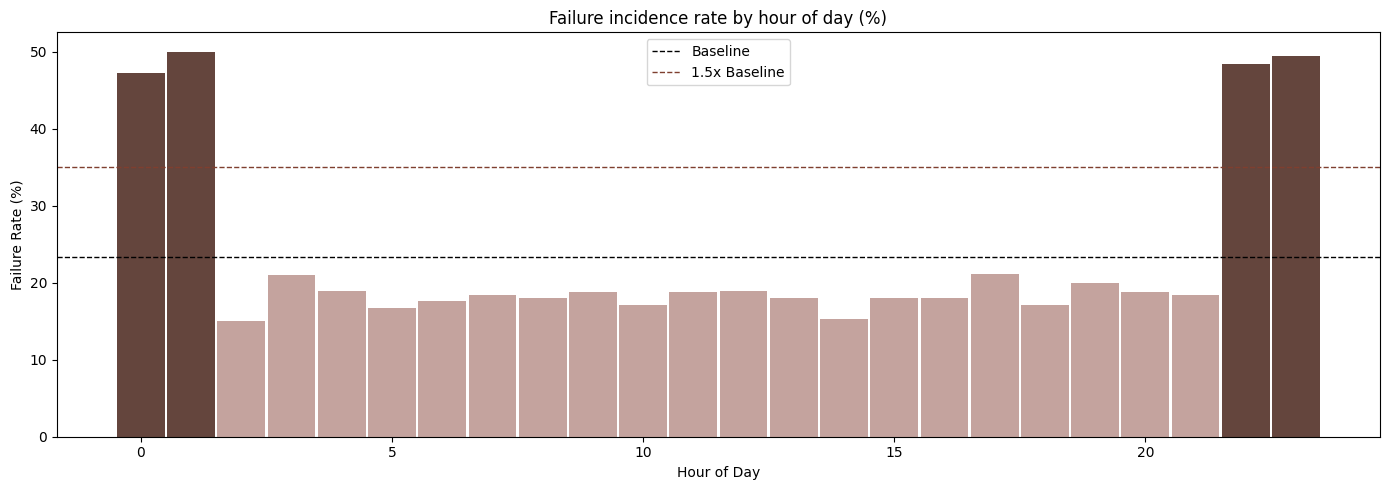

In [4]:
import matplotlib.pyplot as plt

colors = ['#64453d' if rate >threshold else '#c4a39e' for rate in hourly_rate]

plt.figure(figsize=(14, 5))
plt.bar(hourly_rate.index, hourly_rate.values, color=colors, width = 0.95)
plt.axhline(y=baseline, color = 'black', linestyle = '--', linewidth=1, label='Baseline')
plt.axhline(y=threshold, color = "#7f3f2f", linestyle = '--', linewidth=1, label='1.5x Baseline')
plt.title('Failure incidence rate by hour of day (%)')
plt.xlabel('Hour of Day')
plt.ylabel('Failure Rate (%)')  
plt.legend()
plt.tight_layout()
plt.savefig('../charts/hourly_failure_rate.png')
plt.show()

Hours 22, 23, 0, and 1 consistently exceed the 1.5x threshold at over 
35% failure rate. These correspond to bank maintenance windows and 
represent the highest risk period for initiating transactions.

Salary day spike (day 28–31 vs rest)

In [5]:
salary_days = df[df['day_of_month'] >=28]
normal_days = df[df['day_of_month'] < 28]

salary_rate = salary_days['is_failed'].mean()*100
normal_rate = normal_days['is_failed'].mean()*100
spike_factor = round(salary_rate/normal_rate,2)

print("Salary Window Failure Rate:", round(salary_rate,2),"%")
print("Normal Window Failure Rate:", round(normal_rate,2),"%")
print("Salary days are", spike_factor, "x more likely to fail.")

Salary Window Failure Rate: 46.31 %
Normal Window Failure Rate: 20.62 %
Salary days are 2.25 x more likely to fail.


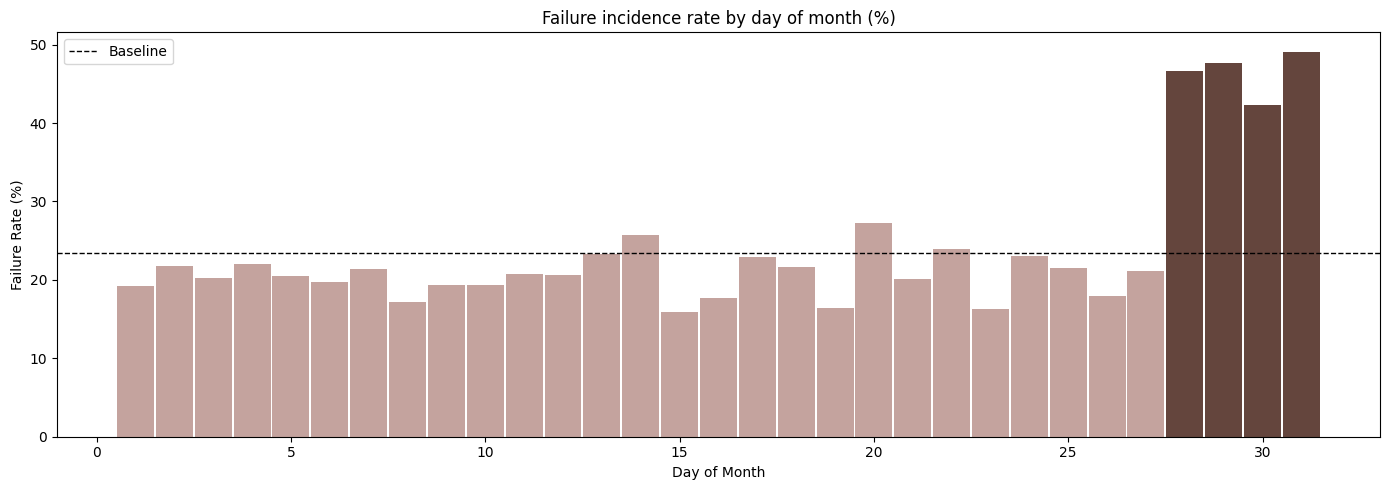

In [6]:
daily_rate = df.groupby('day_of_month')['is_failed'].mean()*100

colors = ['#64453d' if day >=28 else '#c4a39e' for day in daily_rate.index]

plt.figure(figsize=(14, 5))
plt.bar(daily_rate.index, daily_rate.values, color=colors, width = 0.95)
plt.axhline(y=baseline, color = 'black', linestyle = '--', linewidth=1, label='Baseline')
plt.title('Failure incidence rate by day of month (%)')
plt.xlabel('Day of Month')
plt.ylabel('Failure Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../charts/daily_failure_rate.png')
plt.show()

Salary credit days (28–31) show a failure rate of 46.31% compared to 
20.62% on normal days — a 2.25x spike. This pattern is consistent across all channels and confirms server overload during high-volume salary disbursement periods.

Create the High Risk flag

In [8]:
df['is_high_risk'] = (df['hour'].isin([22,23,0,1]))|(df['day_of_month'] >=28).astype(int)
print(df['is_high_risk'].value_counts())

is_high_risk
False    7402
True     2598
Name: count, dtype: int64


In [9]:
high_risk_rate = df[df['is_high_risk']==1]['is_failed'].mean()*100
normal_rate = df[df['is_high_risk']==0]['is_failed'].mean()*100
difference = round(high_risk_rate - normal_rate,2)
multiplier = round(high_risk_rate/normal_rate,2)

print("High Risk Failure Rate:", round(high_risk_rate,2),"%")
print("Normal Failure Rate:", round(normal_rate,2),"%")
print("Difference:",difference,"%")
print("High risk is", multiplier, "x more likely to fail.")

High Risk Failure Rate: 45.73 %
Normal Failure Rate: 15.52 %
Difference: 30.2 %
High risk is 2.95 x more likely to fail.


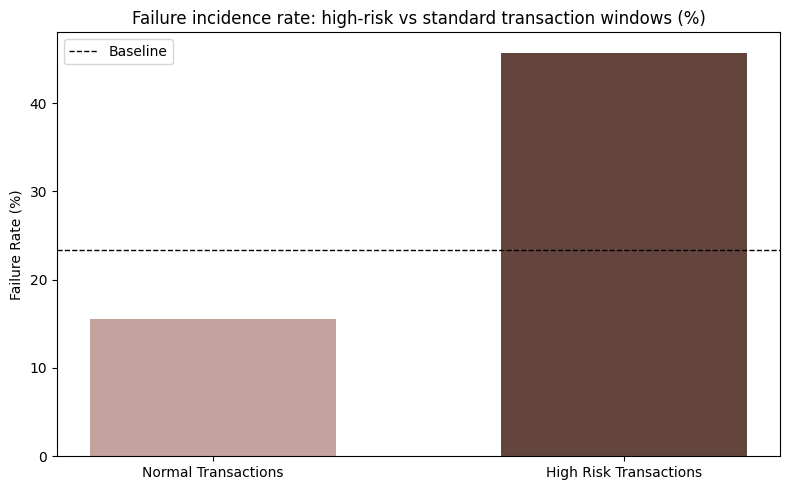

In [10]:
categories = ['Normal Transactions', 'High Risk Transactions']
rates = [normal_rate, high_risk_rate]
colors = ['#c4a39e', '#64453d']

plt.figure(figsize=(8, 5))
plt.bar(categories, rates, color=colors, width = 0.6)
plt.axhline(y=baseline, color = 'black', linestyle = '--', linewidth=1, label='Baseline')
plt.title('Failure incidence rate: high-risk vs standard transaction windows (%)')
plt.ylabel('Failure Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../charts/high_risk_vs_normal.png')
plt.show()

High risk transactions — those initiated during the 10pm–1am maintenance window or on salary credit days — fail at 45.73% compared to 15.52% for normal transactions. This 2.95x difference confirms that time of initiation is a statistically significant predictor of transaction failure, providing banks with a clear signal for when to increase server capacity or display user warnings.

Create one clean table showing total transactions, failure count, and failure rate for each channel side by side

In [4]:
channel_summary = df.groupby('payment_channel').agg(
    total_transactions=('is_failed', 'count'),
    failure_count = ('is_failed','sum')
).reset_index()
channel_summary['failure_rate_%'] = round(channel_summary['failure_count']/channel_summary['total_transactions']*100, 2)
print(channel_summary)

  payment_channel  total_transactions  failure_count  failure_rate_%
0            Card                2017            416           20.62
1            NEFT                2500            419           16.76
2            RTGS                1010             92            9.11
3             UPI                3470           1147           33.05
4          Wallet                1003            263           26.22


Sort the table from above table by failure rate — lowest failure rate = most reliable = rank 1.

In [5]:
channel_summary['reliability_rank'] = channel_summary['failure_rate_%'].rank(ascending=True).astype(int)
channel_ranked = channel_summary.sort_values('failure_rate_%',ascending=True).reset_index(drop=True)
channel_ranked.index += 1
print(channel_ranked[['payment_channel','failure_rate_%','reliability_rank']])

  payment_channel  failure_rate_%  reliability_rank
1            RTGS            9.11                 1
2            NEFT           16.76                 2
3            Card           20.62                 3
4          Wallet           26.22                 4
5             UPI           33.05                 5


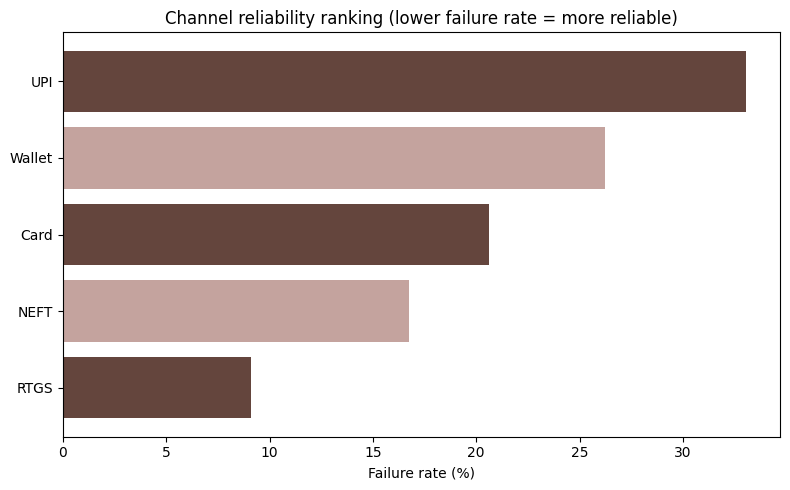

In [13]:
colors = ['#64453d', '#c4a39e'] * len(channel_ranked)
colors = colors[:len(channel_ranked)]

plt.figure(figsize=(8, 5))
plt.barh(channel_ranked['payment_channel'], channel_ranked['failure_rate_%'], color=colors)
plt.title('Channel reliability ranking (lower failure rate = more reliable)')
plt.xlabel('Failure rate (%)')
plt.tight_layout()
plt.savefig('../charts/channel_reliability_ranking.png')
plt.show()

RTGS ranks as the most reliable channel with only 9.11% failure rate 
while UPI is least reliable at 33.05%. Banks should prioritise UPI 
infrastructure improvements given its dominant transaction volume.

Count how many times each failure reason appears across all failed transactions.

In [14]:
error_frequency = df[df['is_failed']==1]['failure_reason'].value_counts()
error_frequency_pct = round(error_frequency / error_frequency.sum() * 100, 2)

error_summary = pd.DataFrame({
    'count': error_frequency,
    'percentage': error_frequency_pct
})
print(error_summary)

                     count  percentage
failure_reason                        
bank_server_timeout    254       10.87
outside_neft_hours     248       10.61
account_blocked        247       10.57
fraud_blocked          238       10.18
invalid_account        234       10.01
network_failure        233        9.97
insufficient_funds     229        9.80
duplicate_txn          227        9.71
wrong_pin              215        9.20
wrong_ifsc             212        9.07


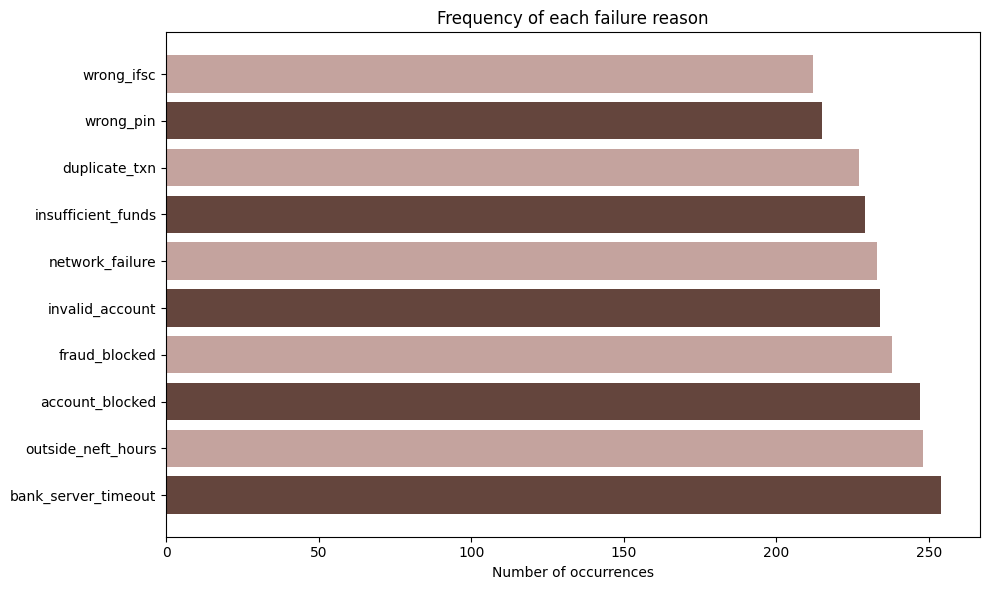

In [15]:
colors = ['#64453d', '#c4a39e'] * len(error_frequency)
colors = colors[:len(error_frequency)]

plt.figure(figsize=(10, 6))
plt.barh(error_frequency.index, error_frequency.values, color=colors)
plt.title('Frequency of each failure reason')
plt.xlabel('Number of occurrences')
plt.tight_layout()
plt.savefig('../charts/error_frequency.png')
plt.show()

In [16]:
upi_night = df[
    (df['payment_channel'] == 'UPI') &
    (df['hour'].isin([22, 23, 0, 1]))
]

neft_day = df[
    (df['payment_channel'] == 'NEFT') &
    (~df['hour'].isin([22, 23, 0, 1]))
]

upi_night_rate = round(upi_night['is_failed'].mean() * 100, 2)
neft_day_rate  = round(neft_day['is_failed'].mean() * 100, 2)
multiplier     = round(upi_night_rate / neft_day_rate, 2)

print("UPI at night failure rate: ", upi_night_rate, "%")
print("NEFT daytime failure rate: ", neft_day_rate, "%")
print("UPI night is", multiplier, "x more likely to fail than NEFT daytime")

UPI at night failure rate:  65.6 %
NEFT daytime failure rate:  12.95 %
UPI night is 5.07 x more likely to fail than NEFT daytime


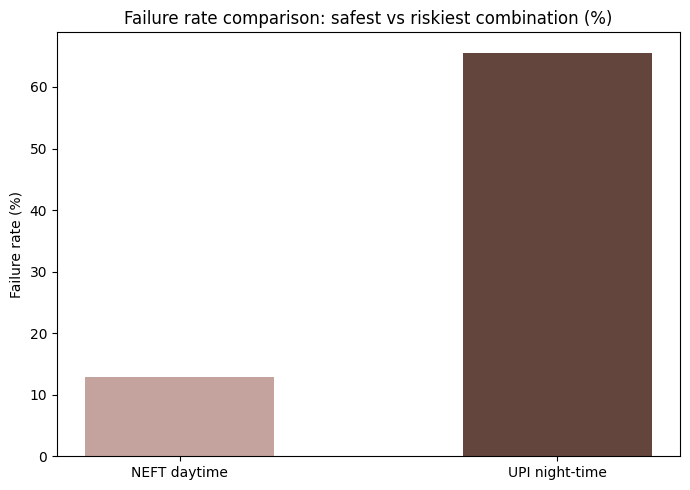

In [17]:
categories = ['NEFT daytime', 'UPI night-time']
rates      = [neft_day_rate, upi_night_rate]
colors     = ['#c4a39e', '#64453d']

plt.figure(figsize=(7, 5))
plt.bar(categories, rates, color=colors, width=0.5)
plt.title('Failure rate comparison: safest vs riskiest combination (%)')
plt.ylabel('Failure rate (%)')
plt.tight_layout()
plt.savefig('../charts/upi_night_vs_neft_day.png')
plt.show()

UPI transactions during night hours fail at 65.6% — more than 5.07x the 
failure rate of NEFT transactions during daytime at 12.95%. This comparison defines the full risk spectrum and demonstrates that both channel choice and timing are independent predictors of transaction failure.